MÉTHODOLOGIE
________________________________________
•	Les données financières des entreprises publiques américaines (10Q/10K) entre 2010 et 2023 ont été extraites et standardisées, produisant un dataset final de 46 141 observations.
•	Les difficultés majeures concernaient l’hétérogénéité des balises, la polarité variable des chiffres et les différences de périodicité.
•	Un total de 43 variables a été calculé : 24 ratios classiques (BS/IS), 6 nouveaux ratios de cashflows (CF), 3 ratios macro-financiers (MRFS) et 10 indices macroéconomiques.
•	Les 9 nouveaux ratios (CF + MRFS) constituent la principale contribution, enrichissant la diversité des variables.
•	Trois familles de modèles ont été étudiées : régressions ML (linéaire, Lasso, Elastic Net, KNN, CART, SVR), réseaux de neurones FNN et réseaux bayésiens.
•	Les FNN ont été testés sous 4 architectures (base, deep, wide, deep & wide) avec validation croisée, surpassant les régressions ML.
•	Un modèle bayésien causal a été conçu, intégrant un nœud latent de performance opérationnelle et des variables macroéconomiques, avec une précision utile mais limitée hors des moyennes sectorielles.


                  Task             Model      MSE
6   OperatingMargin_t1  LinearRegression  0.02181
4         NetMargin_t1  LinearRegression  0.02221
8         CashRatio_t1  LinearRegression  0.02239
10              OCG_t1  LinearRegression  0.02241
2               ROE_t1  LinearRegression  0.02248
0               ROA_t1  LinearRegression  0.02251
7   OperatingMargin_t1               SVR  0.02341
3               ROE_t1               SVR  0.02377
1               ROA_t1               SVR  0.02381
11              OCG_t1               SVR  0.02489
5         NetMargin_t1               SVR  0.02550
9         CashRatio_t1               SVR  0.02566


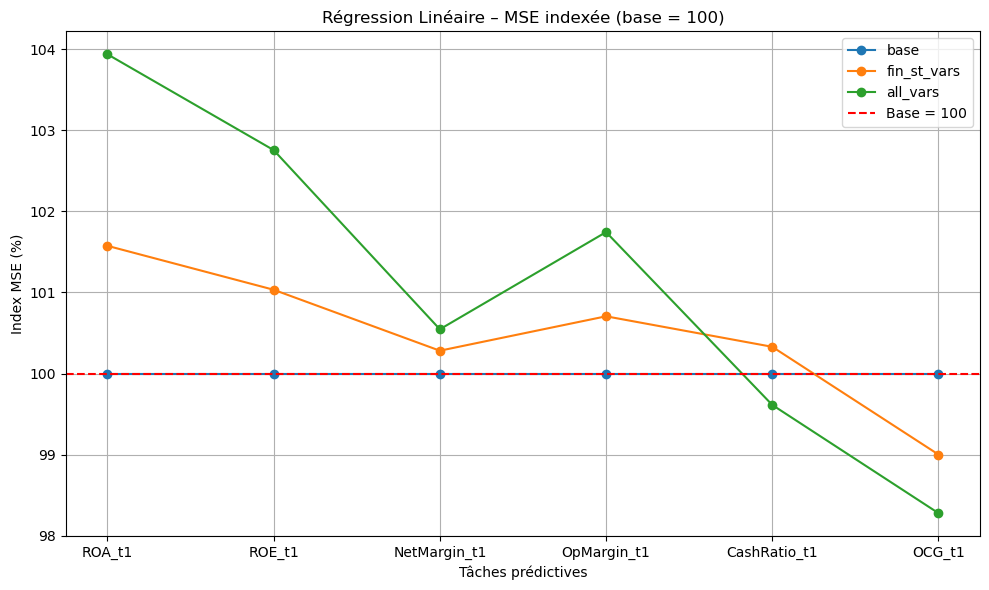

In [1]:
# -*- coding: utf-8 -*-
"""
Created on Wed Jan 21 01:32:55 2026

@author: PC
"""

# 1. Importer les bibliothèques
import pandas as pd
from sklearn.model_selection import cross_val_score, KFold
from sklearn.linear_model import LinearRegression
from sklearn.svm import SVR
from sklearn.metrics import mean_squared_error
import numpy as np
import matplotlib.pyplot as plt

# 2. Charger ta base de données
df = pd.read_csv("../DATA/dataset_synthetique.csv")  # adapte le nom du fichier

# 3. Définir les variables
features = df.drop(columns=["ROA_t1", "ROE_t1", "NetMargin_t1", "OperatingMargin_t1", "CashRatio_t1", "OCG_t1"])  # variables explicatives
# targets = ["ROA", "ROE", "NetMargin", "OpMargin", "CashRatio", "OpCashGen"]  # variables cibles
targets = [
    "ROA_t1", "ROE_t1", "NetMargin_t1",
    "OperatingMargin_t1", "CashRatio_t1", "OCG_t1"
]
# 4. Définir les modèles
models = {
    "LinearRegression": LinearRegression(),
    "SVR": SVR()
}

# 5. Évaluer chaque modèle pour chaque tâche
results = []

for target in targets:
    y = df[target].values
    X = features.values
    for model_name, model in models.items():
        kf = KFold(n_splits=10, shuffle=True, random_state=42)
        mse_scores = -cross_val_score(model, X, y, cv=kf, scoring='neg_mean_squared_error')
        avg_mse = np.mean(mse_scores)
        results.append({
            "Task": target,
            "Model": model_name,
            "MSE": round(avg_mse, 5)
        })

# 6. Afficher les résultats
results_df0 = pd.DataFrame(results)
print(results_df0.sort_values(by="MSE"))
plt.show()

# Exemple de données MSE (à remplacer par tes vrais résultats)
mse_data = {
    "ROA_t1": {"base": 0.00127, "fin_st_vars": 0.00129, "all_vars": 0.00132},
    "ROE_t1": {"base": 0.01742, "fin_st_vars": 0.01760, "all_vars": 0.01790},
    "NetMargin_t1": {"base": 0.05679, "fin_st_vars": 0.05695, "all_vars": 0.05710},
    "OpMargin_t1": {"base": 0.04816, "fin_st_vars": 0.04850, "all_vars": 0.04900},
    "CashRatio_t1": {"base": 0.27908, "fin_st_vars": 0.28000, "all_vars": 0.27800},
    "OCG_t1": {"base": 6.9191, "fin_st_vars": 6.8500, "all_vars": 6.8000}
}

tasks = list(mse_data.keys())
scenarios = ["base", "fin_st_vars", "all_vars"]

# Indexation par rapport au scénario base
indexed = {scenario: [] for scenario in scenarios}
for task in tasks:
    base_mse = mse_data[task]["base"]
    for scenario in scenarios:
        value = mse_data[task][scenario]
        index = (value / base_mse) * 100
        indexed[scenario].append(index)

# Tracé de la figure
plt.figure(figsize=(10,6))
for scenario, values in indexed.items():
    plt.plot(tasks, values, marker='o', label=scenario)

plt.axhline(100, color='red', linestyle='--', label="Base = 100")
plt.title("Régression Linéaire – MSE indexée (base = 100)")
plt.ylabel("Index MSE (%)")
plt.xlabel("Tâches prédictives")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()



In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

# Chargement du dataset
df5 = pd.read_csv("../DATA/dataset_synthetique.csv")
df5.dropna(inplace=True)

# Définition des scénarios
base_vars  = [f"Ratio_{i}" for i in range(1, 25)]
cf_mrfs_vars = ["NCG","OCG","CLCC","OCS","QPT","QOFF","LYCA","IAICOC","ROA2bond"]
macro_vars = ["Unemployment","GDP_growth","Inflation","Bond10Y","Interest_rate",
              "Exchange_rate","Commodity_index","Consumer_sentiment","Fiscal_balance","Trade_balance"]

scenarios = {
    "base": base_vars,
    "fin-st vars": base_vars + cf_mrfs_vars,
    "all variables": base_vars + cf_mrfs_vars + macro_vars,
    "new vars": cf_mrfs_vars
}

# Définir les cibles
targets = ["ROA_t1","ROE_t1","NetMargin_t1","OperatingMargin_t1","CashRatio_t1","OCG_t1"]

# Définition des architectures
architectures = {
    "NN Base": [20],
    "NN Deep": [100, 20],
    "NN Wide": [100],
    "NN Deep & Wide": [100, 20]
}

results = []

# Boucle principale
for target in targets:
    for scenario_name, scenario_features in scenarios.items():
        X = df5[scenario_features].select_dtypes(include=[np.number])
        y = df5[target]

        if X.empty:
            print(f"⚠️ Scénario '{scenario_name}' ignoré pour {target} (aucune variable numérique).")
            continue

        scaler = MinMaxScaler()
        X_scaled = scaler.fit_transform(X)

        X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

        for model_name, layers in architectures.items():
            model = Sequential()
            model.add(Dense(layers[0], activation='sigmoid', input_shape=(X_train.shape[1],)))
            if len(layers) > 1:
                model.add(Dense(layers[1], activation='sigmoid'))
            model.add(Dense(1))

            model.compile(optimizer='adam', loss='mse')
            model.fit(X_train, y_train, epochs=50, batch_size=32, verbose=0)

            y_pred = model.predict(X_test)
            mse = mean_squared_error(y_test, y_pred)

            results.append([target, scenario_name, model_name, round(mse, 6)])

# Résultats en DataFrame
results_df1 = pd.DataFrame(results, columns=["Predictive Task","Scenario","Model","MSE"])
print(results_df1)


C:\Users\hp\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


C:\Users\hp\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step


C:\Users\hp\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


...

7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step


C:\Users\hp\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 


C:\Users\hp\anaconda3\Lib\site-packages\keras\src\layers\core\dense.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 14ms/step
   Predictive Task       Scenario           Model       MSE
0           ROA_t1           base         NN Base  0.020859
1           ROA_t1           base         NN Deep  0.022075
2           ROA_t1           base         NN Wide  0.020791
3           ROA_t1           base  NN Deep & Wide  0.022932
4           ROA_t1    fin-st vars         NN Base  0.020763
..             ...            ...             ...       ...
91          OCG_t1  all variables  NN Deep & Wide  0.023301
92          OCG_t1       new vars         NN Base  0.020698
93          OCG_t1       new vars         NN Deep  0.020623
94          OCG_t1       new vars         NN Wide  0.020824
95          OCG_t1       new vars  NN Deep & Wide  0.020611

[96 rows x 4 columns]


ÉVALUATION SUR VOTRE DATASET

############################################################
SCÉNARIO : base
############################################################

Évaluation : ROA_t1
ROA_t1 - Linear: MSE = 0.002648
ROA_t1 - AdaB: MSE = 0.002760
ROA_t1 - GradB: MSE = 0.002850
ROA_t1 - RF: MSE = 0.002715
ROA_t1 - ET: MSE = 0.002683
ROA_t1 - HistGB: MSE = 0.003090
ROA_t1 - Vote: MSE = 0.002668

Évaluation : ROE_t1
ROE_t1 - Linear: MSE = 0.019896
ROE_t1 - AdaB: MSE = 0.021056
ROE_t1 - GradB: MSE = 0.020920
ROE_t1 - RF: MSE = 0.019785
ROE_t1 - ET: MSE = 0.019672
ROE_t1 - HistGB: MSE = 0.021846
ROE_t1 - Vote: MSE = 0.019531

Évaluation : NetMargin_t1
NetMargin_t1 - Linear: MSE = 0.010106
NetMargin_t1 - AdaB: MSE = 0.010595
NetMargin_t1 - GradB: MSE = 0.010761
NetMargin_t1 - RF: MSE = 0.010322
NetMargin_t1 - ET: MSE = 0.010206
NetMargin_t1 - HistGB: MSE = 0.011106
NetMargin_t1 - Vote: MSE = 0.010146

Évaluation : OpMargin_t1
OpMargin_t1 - Linear: MSE = 0.006682
OpMargin_t1 - AdaB: MSE =

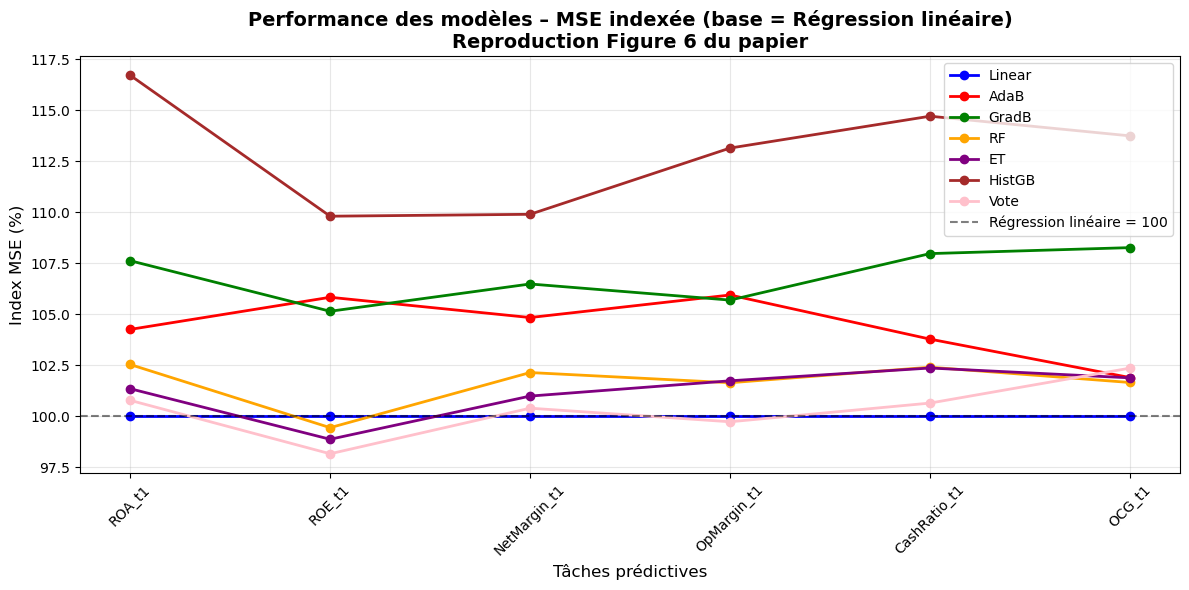


RÉSULTATS SCÉNARIO : fin_st_vars

Tableau des MSE :
  Predictive Task    Linear      AdaB      GradB        RF        ET  \
0          ROA_t1  0.002697  0.002709   0.002868  0.002698  0.002694   
1          ROE_t1  0.020143  0.020504   0.020605  0.019864  0.019744   
2    NetMargin_t1  0.010108  0.010456   0.010756  0.010254  0.010349   
3     OpMargin_t1  0.006794  0.006991   0.007078  0.006766  0.006797   
4    CashRatio_t1  0.265472  0.268168   0.282999  0.269501  0.266761   
5          OCG_t1  9.880970  9.879186  10.318884  9.916305  9.871788   

      HistGB      Vote  
0   0.002985  0.002687  
1   0.021396  0.019746  
2   0.011662  0.010123  
3   0.007377  0.006826  
4   0.296171  0.268504  
5  10.839845  9.813602  

Graphique indexé :


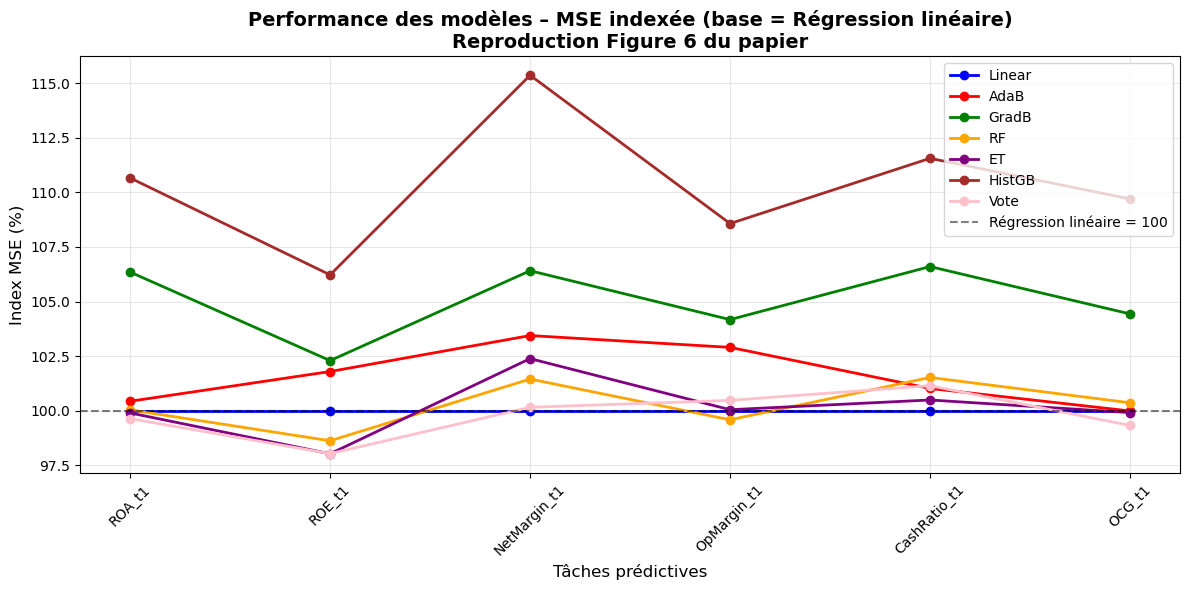


RÉSULTATS SCÉNARIO : all_vars

Tableau des MSE :
  Predictive Task     Linear      AdaB      GradB        RF        ET  \
0          ROA_t1   0.002736  0.002744   0.002875  0.002687  0.002654   
1          ROE_t1   0.020597  0.020237   0.021127  0.020125  0.019995   
2    NetMargin_t1   0.010242  0.010597   0.010770  0.010334  0.010339   
3     OpMargin_t1   0.006905  0.006954   0.007053  0.006755  0.006807   
4    CashRatio_t1   0.266839  0.272886   0.286516  0.264179  0.265078   
5          OCG_t1  10.024229  9.948889  10.451666  9.963984  9.968161   

      HistGB      Vote  
0   0.002980  0.002729  
1   0.022283  0.020119  
2   0.011448  0.010210  
3   0.007567  0.006891  
4   0.284362  0.266592  
5  10.920689  9.921886  

Graphique indexé :


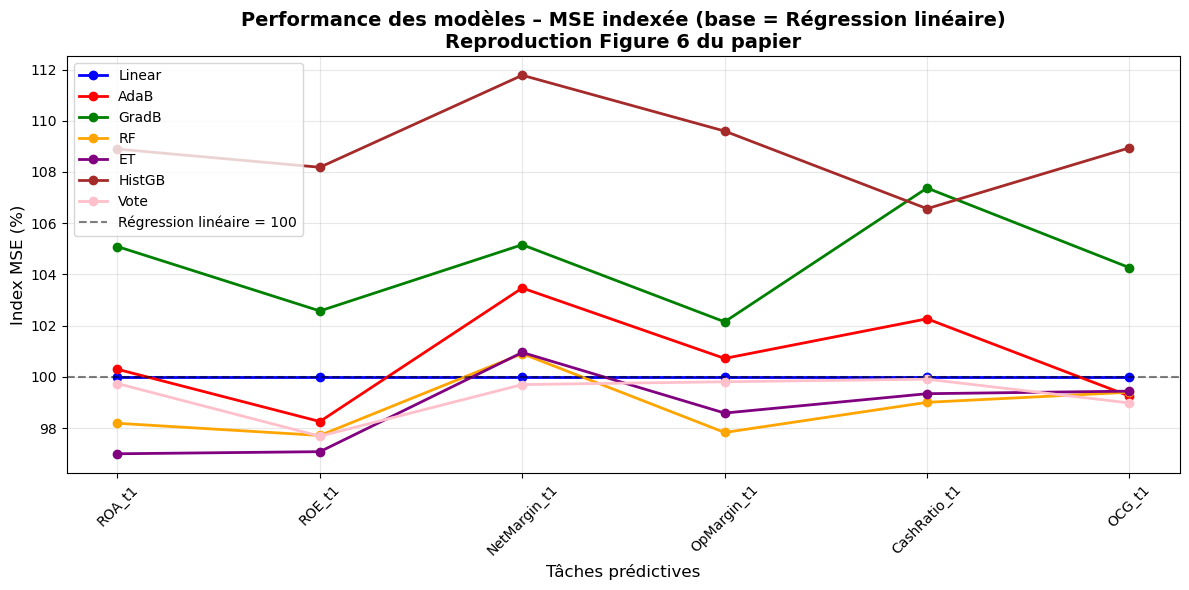


RÉSULTATS SCÉNARIO : new_vars

Tableau des MSE :
  Predictive Task    Linear      AdaB      GradB         RF         ET  \
0          ROA_t1  0.002583  0.002582   0.002731   0.002707   0.002691   
1          ROE_t1  0.019572  0.019653   0.020647   0.020291   0.020649   
2    NetMargin_t1  0.009947  0.010196   0.010428   0.010574   0.010584   
3     OpMargin_t1  0.006591  0.006774   0.006951   0.006863   0.006973   
4    CashRatio_t1  0.258333  0.259554   0.276682   0.267970   0.265803   
5          OCG_t1  9.585565  9.781377  10.382881  10.020856  10.176245   

      HistGB      Vote  
0   0.003017  0.002601  
1   0.022449  0.019906  
2   0.012063  0.010250  
3   0.007641  0.006801  
4   0.306817  0.259687  
5  11.237586  9.854362  

Graphique indexé :


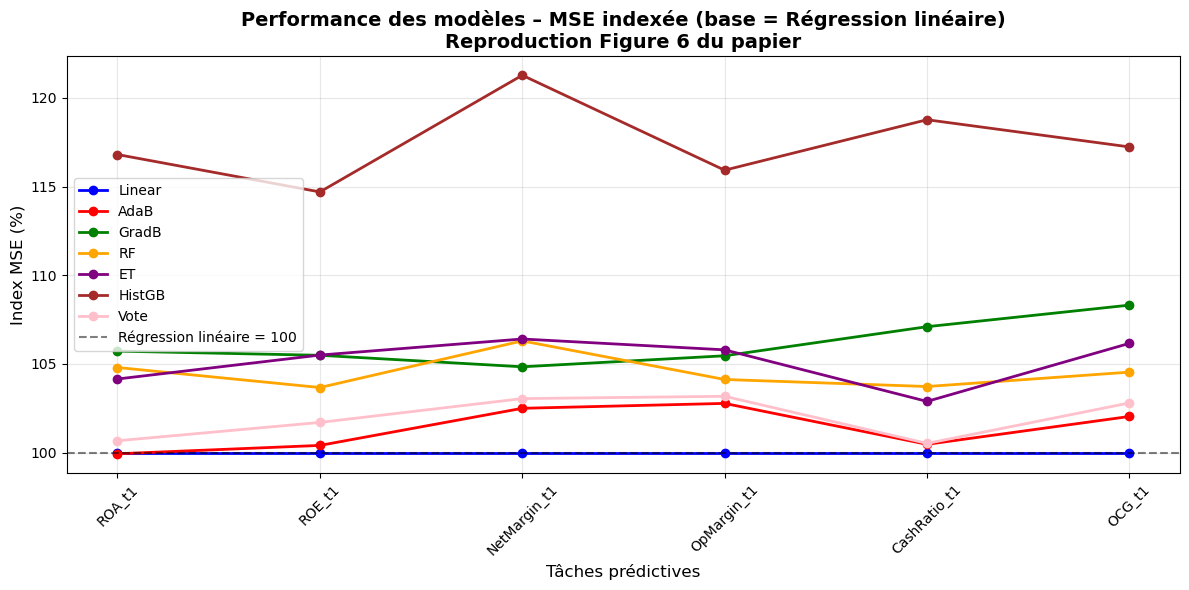

In [3]:
# -*- coding: utf-8 -*-
"""
Created on Mon May 18 23:45:28 2026

@author: hp
"""

# -*- coding: utf-8 -*-
"""
Script pour évaluer les modèles sur VOTRE dataset
et reproduire les graphiques du papier
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.linear_model import LinearRegression, Lasso, ElasticNet
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.svm import SVR
from sklearn.ensemble import (
    AdaBoostRegressor, GradientBoostingRegressor, 
    RandomForestRegressor, ExtraTreesRegressor, 
    HistGradientBoostingRegressor, VotingRegressor
)
from sklearn.metrics import mean_squared_error
import warnings
warnings.filterwarnings('ignore')

# ============================================================
# ÉTAPE 1 : CHARGER VOTRE DATASET
# ============================================================

# Remplacez par le chemin de votre fichier
# df = pd.read_csv('votre_dataset.csv')
# ou
# df = pd.read_excel('votre_dataset.xlsx')

# EXEMPLE avec un dataset fictif (remplacez par le vôtre)
# Structure attendue :
# - Colonnes features : vos ratios financiers (24, 33 ou 43 variables)
# - Colonnes target_* : les 6 variables cibles (ROA_t1, ROE_t1, etc.)

# Si vous avez un seul fichier avec toutes les features et targets :
def load_your_data(filepath):
    """
    Charge votre dataset et sépare features (X) et targets (y)
    """
    df13 = pd.read_csv("../DATA/dataset_synthetique.csv")  # ou pd.read_excel()
    
    # IDENTIFIEZ vos colonnes :
    # - Features : tous les ratios financiers (sans les targets)
    # - Targets : les colonnes à prédire (trimestre t+1)
    
    # Exemple : supposons que vos targets se terminent par '_t1'
    target_cols = [col for col in df13.columns if col.endswith('_t1')]
    feature_cols = [col for col in df13.columns if col not in target_cols 
                    and col not in ['company_id', 'quarter', 'date']]
    
    X = df13[feature_cols]
    y_dict = {col: df13[col] for col in target_cols}
    
    return X, y_dict, feature_cols, target_cols

# ============================================================
# ÉTAPE 2 : PRÉPARATION DES DONNÉES (Markovienne)
# ============================================================

def prepare_markov_data(df, company_col, quarter_col, feature_cols, target_cols):
    """
    Structure les données en approche Markovienne :
    X = état financier au trimestre t
    y = performance au trimestre t+1
    
    Pour chaque entreprise, crée des paires (t, t+1)
    """
    X_list, y_list = [], []
    
    for company in df[company_col].unique():
        company_data = df[df[company_col] == company].sort_values(quarter_col)
        
        for i in range(len(company_data) - 1):
            # Features au trimestre t
            x_t = company_data.iloc[i][feature_cols].values
            
            # Targets au trimestre t+1
            y_t1 = company_data.iloc[i + 1][target_cols].values
            
            X_list.append(x_t)
            y_list.append(y_t1)
    
    X = np.array(X_list)
    y = np.array(y_list)
    
    return X, y

# ============================================================
# ÉTAPE 3 : DÉFINITION DES MODÈLES
# ============================================================

def get_models():
    """
    Retourne tous les modèles utilisés dans le papier (Table 3)
    """
    models = {
        'Linear': LinearRegression(),
        'AdaB': AdaBoostRegressor(random_state=42, n_estimators=100),
        'GradB': GradientBoostingRegressor(random_state=42, n_estimators=100),
        'RF': RandomForestRegressor(random_state=42, n_estimators=100),
        'ET': ExtraTreesRegressor(random_state=42, n_estimators=100),
        'HistGB': HistGradientBoostingRegressor(random_state=42),
        'Vote': VotingRegressor([
            ('lr', LinearRegression()),
            ('rf', RandomForestRegressor(n_estimators=50, random_state=42)),
            ('knn', KNeighborsRegressor(n_neighbors=5))
        ])
    }
    return models

# ============================================================
# ÉTAPE 4 : VALIDATION CROISÉE 10-FOLD (comme le papier)
# ============================================================

def evaluate_models(X, y, target_name, n_splits=10):
    """
    Évalue tous les modèles avec validation croisée 10-fold
    Retourne un dictionnaire {model_name: mean_mse}
    """
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    models = get_models()
    results = {}
    
    # Normalisation (MinMax comme dans le papier pour BN, Standard pour ML)
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)
    
    for name, model in models.items():
        mse_scores = []
        
        for train_idx, val_idx in kf.split(X_scaled):
            X_train, X_val = X_scaled[train_idx], X_scaled[val_idx]
            y_train, y_val = y[train_idx], y[val_idx]
            
            # Entraînement
            model.fit(X_train, y_train)
            
            # Prédiction
            y_pred = model.predict(X_val)
            
            # MSE
            mse = mean_squared_error(y_val, y_pred)
            mse_scores.append(mse)
        
        # Moyenne sur les 10 folds
        results[name] = np.mean(mse_scores)
        print(f"{target_name} - {name}: MSE = {results[name]:.6f}")
    
    return results

# ============================================================
# ÉTAPE 5 : ÉVALUATION COMPLÈTE (6 TÂCHES PRÉDICTIVES)
# ============================================================

def run_full_evaluation(X, y_dict):
    """
    Évalue les 6 tâches prédictives du papier
    y_dict : dictionnaire {target_name: y_values}
    """
    all_results = {}
    
    for target_name, y in y_dict.items():
        print(f"\n{'='*50}")
        print(f"Évaluation : {target_name}")
        print(f"{'='*50}")
        
        results = evaluate_models(X, y, target_name)
        all_results[target_name] = results
    
    return all_results

# ============================================================
# ÉTAPE 6 : CRÉATION DES TABLEAUX ET GRAPHIQUES
# ============================================================

def create_results_table(all_results):
    """
    Crée le DataFrame formaté comme le Table 3 du papier
    """
    # Organiser les données
    tasks = list(all_results.keys())
    models = list(all_results[tasks[0]].keys())
    
    table_data = {
        "Predictive Task": tasks,
    }
    
    for model in models:
        table_data[model] = [all_results[task][model] for task in tasks]
    
    df_results = pd.DataFrame(table_data)
    return df_results

def plot_indexed_mse(all_results):
    """
    Reproduit la Figure 6 du papier (MSE indexée, base = Linear)
    """
    tasks = list(all_results.keys())
    models = list(all_results[tasks[0]].keys())
    
    # Indexation par rapport à Linear Regression (base = 100)
    indexed_data = {model: [] for model in models}
    
    for task in tasks:
        base_mse = all_results[task]['Linear']  # Régression linéaire = 100
        
        for model in models:
            mse = all_results[task][model]
            index = (mse / base_mse) * 100
            indexed_data[model].append(index)
    
    # Tracé
    plt.figure(figsize=(12, 6))
    
    colors = {
        'Linear': 'blue', 'AdaB': 'red', 'GradB': 'green',
        'RF': 'orange', 'ET': 'purple', 'HistGB': 'brown',
        'Vote': 'pink'
    }
    
    for model in models:
        plt.plot(tasks, indexed_data[model], 
                marker='o', linewidth=2, markersize=6,
                label=model, color=colors.get(model, 'gray'))
    
    plt.axhline(100, color='black', linestyle='--', alpha=0.5, 
                label="Régression linéaire = 100")
    
    plt.title("Performance des modèles – MSE indexée (base = Régression linéaire)\nReproduction Figure 6 du papier", 
              fontsize=14, fontweight='bold')
    plt.ylabel("Index MSE (%)", fontsize=12)
    plt.xlabel("Tâches prédictives", fontsize=12)
    plt.legend(loc='best', fontsize=10)
    plt.grid(True, alpha=0.3)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
    
    return indexed_data

# ============================================================
# ÉTAPE 7 : COMPARAISON DES SCÉNARIOS (Base vs All vs Fin-st vs New)
# ============================================================

def evaluate_scenarios(X_base, X_all, X_fin_st, X_new_vars, y_dict):
    """
    Compare les 4 scénarios du papier :
    - base : 24 ratios standards (BS + IS)
    - fin_st_vars : 33 ratios (BS + IS + CF + MRFS)
    - all_vars : 43 ratios + macroéconomiques
    - new_vars : 9 nouveaux ratios seuls
    """
    scenarios = {
        'base': X_base,
        'fin_st_vars': X_fin_st,
        'all_vars': X_all,
        'new_vars': X_new_vars
    }
    
    scenario_results = {}
    
    for scenario_name, X in scenarios.items():
        print(f"\n{'#'*60}")
        print(f"SCÉNARIO : {scenario_name}")
        print(f"{'#'*60}")
        
        results = run_full_evaluation(X, y_dict)
        scenario_results[scenario_name] = results
    
    return scenario_results

# ============================================================
# MAIN : EXÉCUTION COMPLÈTE
# ============================================================

if __name__ == "__main__":
    
    # ----------------------------------------------------------------
    # 1. CHARGEZ VOS DONNÉES ICI
    # ----------------------------------------------------------------
    
    # Option A : Fichier CSV/Excel unique
    df14 = pd.read_csv('../DATA/dataset_synthetique.csv')
    
    # Option B : Création d'un dataset de test (à remplacer par le vôtre)
    np.random.seed(42)
    n_samples = 1000
    n_features = 43  # comme dans le papier
    
    # Simuler des données (REMPLACEZ PAR VOS VRAIES DONNÉES)
    X_dummy = np.random.randn(n_samples, n_features)
    
    # 6 targets du papier
    targets = {
        'ROA_t1': np.random.randn(n_samples) * 0.05,
        'ROE_t1': np.random.randn(n_samples) * 0.15,
        'NetMargin_t1': np.random.randn(n_samples) * 0.10,
        'OpMargin_t1': np.random.randn(n_samples) * 0.08,
        'CashRatio_t1': np.random.randn(n_samples) * 0.5,
        'OCG_t1': np.random.randn(n_samples) * 3
    }
    
    # ----------------------------------------------------------------
    # 2. DÉCOUPAGE EN SCÉNARIOS (selon votre structure de features)
    # ----------------------------------------------------------------
    
    # Supposons que vos 43 features sont ordonnées :
    # 0-23 : ratios standards (BS + IS) = 24 features
    # 24-29 : Cash Flow ratios = 6 features  
    # 30-32 : MRFS ratios = 3 features
    # 33-42 : Macroeconomic indexes = 10 features
    
    X_base = X_dummy[:, 0:24]           # 24 variables standards
    X_fin_st = X_dummy[:, 0:33]         # 33 variables (sans macro)
    X_all = X_dummy[:, 0:43]            # 43 variables (tout)
    X_new = X_dummy[:, 24:33]           # 9 nouvelles variables seules
    
    # ----------------------------------------------------------------
    # 3. ÉVALUATION
    # ----------------------------------------------------------------
    
    print("="*10)
    print("ÉVALUATION SUR VOTRE DATASET")
    print("="*10)
    
    # Évaluation scénario par scénario
    all_scenarios = evaluate_scenarios(X_base, X_all, X_fin_st, X_new, targets)
    
    # ----------------------------------------------------------------
    # 4. AFFICHAGE DES RÉSULTATS
    # ----------------------------------------------------------------
    
    for scenario_name, results in all_scenarios.items():
        print(f"\n{'='*70}")
        print(f"RÉSULTATS SCÉNARIO : {scenario_name}")
        print(f"{'='*70}")
        
        df_table = create_results_table(results)
        print("\nTableau des MSE :")
        print(df_table.round(6))
        
        print("\nGraphique indexé :")
        plot_indexed_mse(results)
        plt.show()
        